## 0. import

In [53]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. 데이터 준비

In [54]:
RANDOM_STATE = 203

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

def to_grade(q):
    if q <= 4:
        return 'low'
    elif q <= 6:
        return 'medium'
    else:
        return 'high'

df['grade'] = df['quality'].apply(to_grade)

X = df.drop(columns=['quality', 'grade'])
y = df['grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

## 2. AdaBoost 실습

In [55]:
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)
ada_clf.fit(X_train, y_train)
ada_pred = ada_clf.predict(X_test)
print('AdaBoost 정확도: {0:.4f}'.format(accuracy_score(y_test, ada_pred)))

AdaBoost 정확도: 0.8063


In [56]:
# --- 단일 약한 학습기(그루터기) vs AdaBoost 비교 ---
stump_clf = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
stump_clf.fit(X_train, y_train)
stump_pred = stump_clf.predict(X_test)
stump_acc = accuracy_score(y_test, stump_pred)
print('단일 약한 학습기(그루터기) 정확도: {0:.4f}'.format(stump_acc))
print('AdaBoost(50개 결합) 정확도: {0:.4f}'.format(accuracy_score(y_test, ada_pred)))


print(confusion_matrix(y_test, ada_pred))
print(classification_report(y_test, ada_pred))

단일 약한 학습기(그루터기) 정확도: 0.8250
AdaBoost(50개 결합) 정확도: 0.8063
[[ 18   0  25]
 [  0   2  11]
 [ 19   7 238]]
              precision    recall  f1-score   support

        high       0.49      0.42      0.45        43
         low       0.22      0.15      0.18        13
      medium       0.87      0.90      0.88       264

    accuracy                           0.81       320
   macro avg       0.53      0.49      0.51       320
weighted avg       0.79      0.81      0.80       320



In [57]:
# --- n_estimators를 늘려가며 성능 변화 확인 ---
ada_results = []
for n in [1, 10, 50, 100, 200]:
    ada = AdaBoostClassifier(n_estimators=n, random_state=RANDOM_STATE)
    ada.fit(X_train, y_train)
    acc = accuracy_score(y_test, ada.predict(X_test))
    ada_results.append((n, acc))

ada_results_df = pd.DataFrame(ada_results, columns=['n_estimators', 'test_accuracy'])
print(ada_results_df)

   n_estimators  test_accuracy
0             1       0.825000
1            10       0.818750
2            50       0.821875
3           100       0.806250
4           200       0.765625


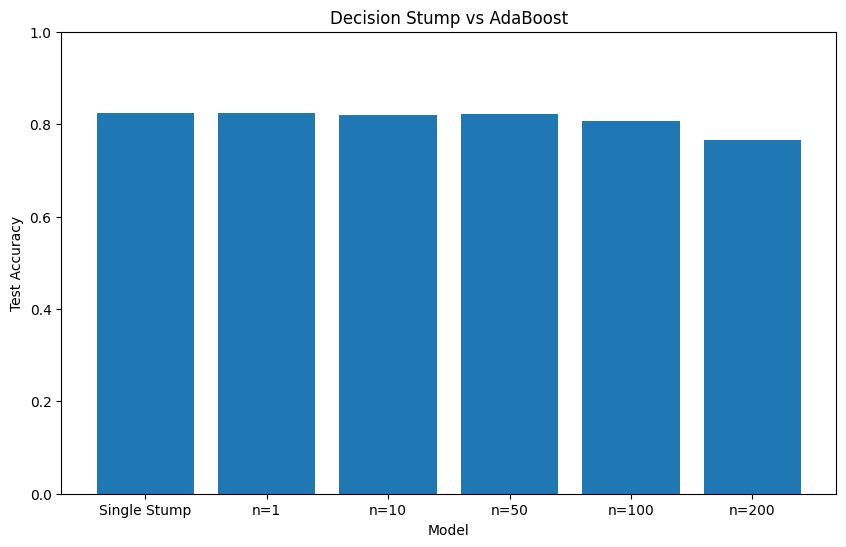

In [58]:
labels = ["Single Stump", "n=1", "n=10", "n=50", "n=100", "n=200"]

acc_list = [stump_acc] + ada_results_df['test_accuracy'].tolist()

plt.figure(figsize=(10, 6))

plt.bar(labels, acc_list)

plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.title('Decision Stump vs AdaBoost')
plt.ylim(0, 1)

plt.show()

## 3. GBM 실습 + 수행 시간 측정

In [59]:
start_time = time.time()
gb_clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print('GBM 수행 시간: {0:.1f} 초'.format(time.time() - start_time))

GBM 정확도: 0.8344
GBM 수행 시간: 1.4 초


In [60]:
# 랜덤포레스트와 비교
start_time = time.time()
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print('랜덤포레스트 정확도: {0:.4f}'.format(accuracy_score(y_test, rf_pred)))
print('랜덤포레스트 수행 시간: {0:.1f} 초'.format(time.time() - start_time))

랜덤포레스트 정확도: 0.8531
랜덤포레스트 수행 시간: 0.3 초


## 4. learning_rate x n_estimators 튜닝

In [61]:
results = []
for lr in [0.01, 0.05, 0.1, 0.2]:
    for n_est in [100, 200]:
        gb = GradientBoostingClassifier(
            learning_rate=lr, n_estimators=n_est, random_state=RANDOM_STATE
        )
        gb.fit(X_train, y_train)
        acc = accuracy_score(y_test, gb.predict(X_test))
        results.append((lr, n_est, acc))

results_df = pd.DataFrame(results, columns=['learning_rate', 'n_estimators', 'test_accuracy'])
print(results_df)

   learning_rate  n_estimators  test_accuracy
0           0.01           100       0.840625
1           0.01           200       0.831250
2           0.05           100       0.843750
3           0.05           200       0.834375
4           0.10           100       0.834375
5           0.10           200       0.850000
6           0.20           100       0.846875
7           0.20           200       0.856250


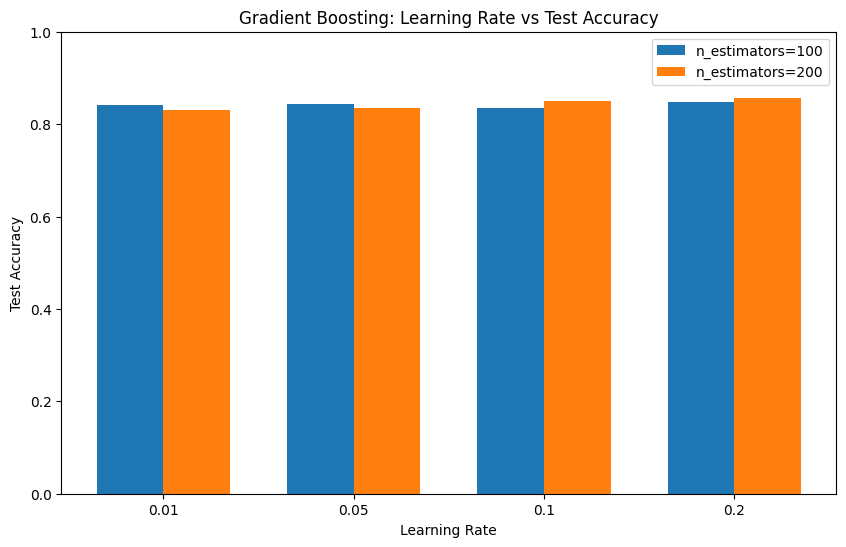

In [62]:
learning_rates = results_df['learning_rate'].unique()
n_estimators = results_df['n_estimators'].unique()

x = np.arange(len(learning_rates))
width = 0.35

plt.figure(figsize=(10, 6))

for i, n_est in enumerate(n_estimators):
    accs = results_df[
        results_df['n_estimators'] == n_est
    ]['test_accuracy']

    plt.bar(
        x + i * width,
        accs,
        width,
        label=f'n_estimators={n_est}'
    )

plt.xticks(x + width / 2, learning_rates)
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title('Gradient Boosting: Learning Rate vs Test Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.show()

## 5. 성능/시간 요약

In [63]:
summary = pd.DataFrame({
    'model': ['AdaBoost', 'GBM(default)', 'RandomForest'],
    'test_accuracy': [
        accuracy_score(y_test, ada_pred),
        gb_accuracy,
        accuracy_score(y_test, rf_pred),
    ]
})
print(summary)

          model  test_accuracy
0      AdaBoost       0.806250
1  GBM(default)       0.834375
2  RandomForest       0.853125
